# Sentiment Analysis - Baseline Model

## Objective

The objective of this notebook is to build a baseline sentiment analysis model using classical Machine Learning.

Pipeline:

- Load cleaned dataset
- Convert text into numerical features using TF-IDF
- Split the dataset
- Train Logistic Regression
- Evaluate the model
- Save the trained model
- Save the TF-IDF vectorizer

In [67]:
!pip install scikit-learn joblib


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [68]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [69]:
df = pd.read_csv("../data/processed/cleaned_reviews.csv")

df.head()

,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,Review Length,Sentiment,Clean Review
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,53,Positive,absolutely wonderful silky sexy comfortable
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses,303,Positive,love dress sooo pretty happened find store im ...
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,500,Neutral,high hope dress really wanted work initially o...
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,124,Positive,love love love jumpsuit fun flirty fabulous ev...
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,192,Positive,shirt flattering due adjustable front tie perf...


In [70]:
df["Sentiment"].value_counts()

Sentiment
Positive    17448
Neutral      2823
Negative     2370
Name: count, dtype: int64

# TF-IDF Vectorization

## Objective

Machine Learning algorithms cannot understand raw text.

Therefore, we convert the cleaned reviews into numerical feature vectors using the TF-IDF (Term Frequency - Inverse Document Frequency) technique.

These vectors will be used to train our Logistic Regression model.

In [71]:
from sklearn.feature_extraction.text import TfidfVectorizer

## Prepare Features and Target

- X → Clean Review (Input Feature)
- y → Sentiment (Target Variable)

In [72]:
X = df["Clean Review"]

y = df["Sentiment"]

In [73]:
X.head()

0          absolutely wonderful silky sexy comfortable
1    love dress sooo pretty happened find store im ...
2    high hope dress really wanted work initially o...
3    love love love jumpsuit fun flirty fabulous ev...
4    shirt flattering due adjustable front tie perf...
Name: Clean Review, dtype: str

In [74]:
y.head()

0    Positive
1    Positive
2     Neutral
3    Positive
4    Positive
Name: Sentiment, dtype: str

## Create TF-IDF Vectorizer

The vectorizer converts textual reviews into numerical vectors based on the importance of words.

In [75]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

## Transform Text into Numerical Features

In [76]:
X = tfidf.fit_transform(X)

In [77]:
X.shape

(22641, 5000)

In [78]:
len(tfidf.vocabulary_)

5000

In [79]:
list(tfidf.vocabulary_.items())[:20]

[('absolutely', np.int64(5)),
 ('wonderful', np.int64(4842)),
 ('silky', np.int64(3742)),
 ('sexy', np.int64(3634)),
 ('comfortable', np.int64(697)),
 ('love', np.int64(2502)),
 ('dress', np.int64(1068)),
 ('sooo', np.int64(3998)),
 ('pretty', np.int64(3226)),
 ('happened', np.int64(1861)),
 ('find', np.int64(1442)),
 ('store', np.int64(4075)),
 ('im', np.int64(2004)),
 ('glad', np.int64(1695)),
 ('bc', np.int64(242)),
 ('never', np.int64(2817)),
 ('would', np.int64(4893)),
 ('ordered', np.int64(2947)),
 ('online', np.int64(2917)),
 ('petite', np.int64(3106))]

## Train-Test Split

The dataset is divided into training and testing sets.

- Training Set (80%) → Used to train the model.
- Testing Set (20%) → Used to evaluate the model on unseen data.

This helps us measure how well the model generalizes to new customer reviews.

In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [81]:
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

Training Features: (18112, 5000)
Testing Features : (4529, 5000)
Training Labels : (18112,)
Testing Labels  : (4529,)


## Train Logistic Regression Model

Logistic Regression is a simple yet powerful algorithm for text classification.

It is widely used as a baseline model for sentiment analysis because it performs well with TF-IDF features and is fast to train.

In [82]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [83]:
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

## Make Predictions

Use the trained model to predict the sentiment of the test dataset.

In [84]:
y_pred = model.predict(X_test)

## Model Accuracy

In [85]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.8218


## Classification Report

The classification report provides:

- Precision
- Recall
- F1-Score
- Support

for each sentiment class.

In [86]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negative       0.63      0.43      0.51       474
     Neutral       0.44      0.22      0.29       565
    Positive       0.87      0.97      0.92      3490

    accuracy                           0.82      4529
   macro avg       0.64      0.54      0.57      4529
weighted avg       0.79      0.82      0.80      4529



## Confusion Matrix

A confusion matrix helps us visualize how many predictions were correct and where the model made mistakes.

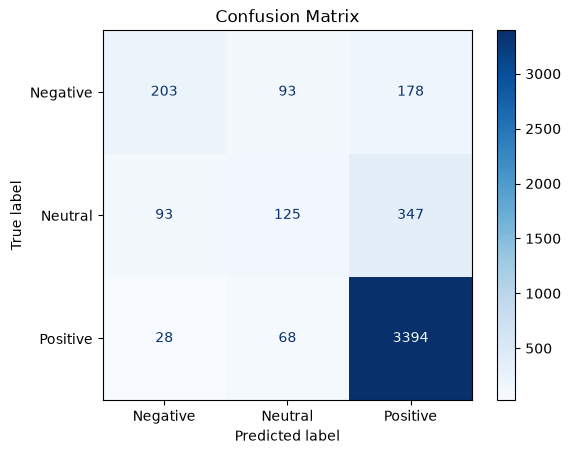

In [87]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

# Save Model

The trained Logistic Regression model and the TF-IDF vectorizer are saved so they can be loaded later without retraining.

These files will be used by the FastAPI backend during inference.

In [88]:
import os
import joblib

# Create models directory if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save Logistic Regression model
joblib.dump(model, "../models/sentiment_model.pkl")

# Save TF-IDF Vectorizer
joblib.dump(tfidf, "../models/vectorizer.pkl")

print("Model and Vectorizer saved successfully!")

Model and Vectorizer saved successfully!


# Test Saved Model

Load the saved model and test it on a custom review.

In [89]:
loaded_model = joblib.load("../models/sentiment_model.pkl")

loaded_vectorizer = joblib.load("../models/vectorizer.pkl")

In [90]:
sample_review = [
    "This dress is absolutely beautiful and fits perfectly."
]

sample_vector = loaded_vectorizer.transform(sample_review)

prediction = loaded_model.predict(sample_vector)

print("Prediction:", prediction[0])

Prediction: Positive


In [96]:
reviews = [
    "best product I have ever purchased.",
    "The dress is okay. nothing special",
    "worst product ever."
]

vectors = loaded_vectorizer.transform(reviews)

predictions = loaded_model.predict(vectors)

for review, sentiment in zip(reviews, predictions):
    print(f"Review: {review}")
    print(f"Predicted Sentiment: {sentiment}")
    print("-" * 50)

Review: best product I have ever purchased.
Predicted Sentiment: Positive
--------------------------------------------------
Review: The dress is okay. nothing special
Predicted Sentiment: Neutral
--------------------------------------------------
Review: worst product ever.
Predicted Sentiment: Negative
--------------------------------------------------
